In [1]:
import os
os.chdir('./stat_csv')
os.getcwd()

'/home/tako/Kasetsart/statistics/stat_csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### Load Dataset

In [3]:
orig_df = pd.read_csv("wholesale_customers_data.csv")
orig_df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


array([[<Axes: title={'center': 'Channel'}>,
        <Axes: title={'center': 'Region'}>,
        <Axes: title={'center': 'Fresh'}>],
       [<Axes: title={'center': 'Milk'}>,
        <Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>, <Axes: >]], dtype=object)

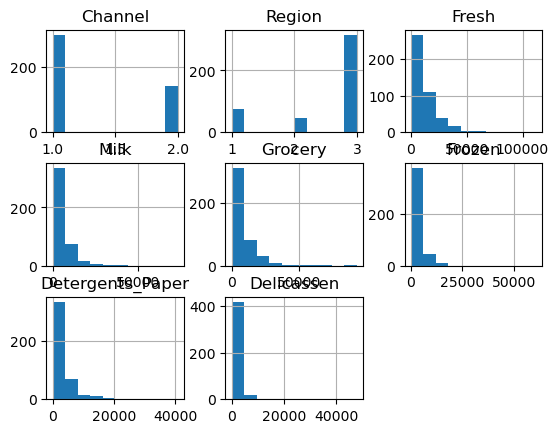

In [4]:
orig_df.hist()

In [5]:
df = orig_df.copy()

### Handling missing values

<Axes: >

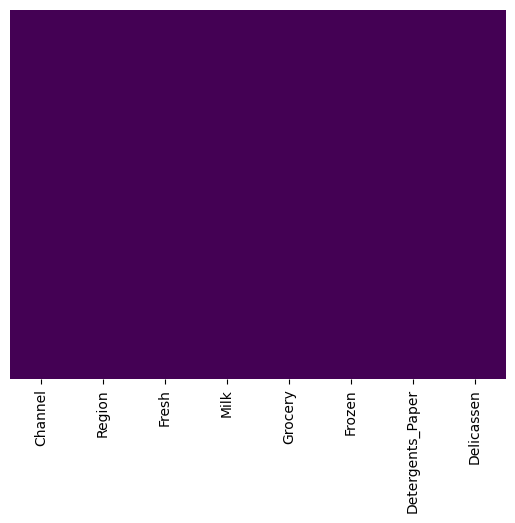

In [6]:
# Plot heatmap to visualize locations of missing values
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

### Handling outliers

In [7]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    col_names = df.columns.tolist()
    new_df = pd.DataFrame(temp_df, col_names)
    return temp_df

### Transform skewed data

In [8]:
def transform_log(X, skew_var):
    temp_X = X.copy()
    temp_X[skew_var] = np.log1p(temp_X[skew_var])   # log1p = log(1 + y)
    return temp_X
    
def transform_boxcox(X, skew_var):
    temp_X = X.copy()
    from scipy.stats import boxcox
    temp_bc, lambda_bc = boxcox(temp_X[skew_var])
    temp_X[skew_var] = temp_bc
    return temp_X

def transform_yeojohnson(X, skew_var):
    temp_X = X.copy()
    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='yeo-johnson')
    temp_X[skew_var] = pt.fit_transform(temp_X[[skew_var]])
    return temp_X

### Encoding categorical data

In [9]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

In [10]:
# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Scaling

In [11]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Scale by robust, (x-median)/iqr
def scale_minmax(X):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

### Removing Redundancy

In [12]:
def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr().abs()

    # Upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features to drop
    dropped_vars = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Drop redundant features
    df_reduced = df.drop(columns=dropped_vars)
    
    return df_reduced, dropped_vars

def remove_low_variance(df, threshold=0.01):
    from sklearn.feature_selection import VarianceThreshold

    selector = VarianceThreshold(threshold)
    df_reduced = selector.fit_transform(df)

    kept_vars = df.columns[selector.get_support()]
    kept_vars = kept_vars.tolist()
    
    new_df = pd.DataFrame(df_reduced, columns=kept_vars)
    return new_df, kept_vars

### Performance Evaluation

In [13]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute cluster centroids
    centroids = np.array([
        X[labels == k].mean(axis=0) for k in unique_clusters
    ])
    
    from scipy.spatial.distance import cdist
    # Inter-cluster distance (minimum distance between clusters)
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )

    # Intra-cluster distance (maximum cluster diameter)
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    silhouette = silhouette_score(X, X_clusters)
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

### Interpretability 

In [14]:
def create_radar_graph(X, X_clusters):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()
    
    # plot Radar Chart  for cluster means
    labels = cluster_means.columns
    num_features = len(labels)
    
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]
    
    plt.figure(figsize=(6, 6))
    
    for i, row in cluster_means.iterrows():
        values = row.tolist()
        values += values[:1]
        plt.polar(angles, values, label=f"Cluster {i}")
    
    plt.xticks(angles[:-1], labels, fontsize=9)
    plt.title("Cluster Profiles (Feature Means)")
    plt.legend()
    plt.show()

In [15]:
def create_feature_boxplots(X, X_clusters):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()

    # plot boxplots of feature values 
    for col in X.columns:
        clustered_df.boxplot(column=col, by="Cluster", figsize=(6, 4))
        plt.title(f"{col} by Cluster")
        plt.suptitle("")
        plt.show()

In [16]:
def create_pca_scatterplot(X_scaled, X_clusters):
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(7,5))
    unique_clusters = np.unique(X_clusters)
    for cluster_id in unique_clusters:
        idx = X_clusters == cluster_id
        plt.scatter(X_pca[idx, 0],
                    X_pca[idx, 1],
                    s=40,
                    label=f"Cluster {cluster_id}"
                   )
    
    plt.title("PCA 2D Scatterplot of Clusters")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(title="Cluster ID")
    plt.show()

In [17]:
def get_permutation_importance(X_scaled, X_clusters):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.inspection import permutation_importance
    
    # Construct proxy classifier
    rf = RandomForestClassifier(random_state=23)
    rf.fit(X_scaled, X_clusters)

    # Compute permutation importance
    perm_importance = permutation_importance(rf, X_scaled, X_clusters, n_repeats=10, random_state=23)
    importance_df = pd.DataFrame({
        'Feature': df.columns,
        'Importance': perm_importance['importances_mean']
    }).sort_values(by='Importance', ascending=False)
    
    return importance_df

In [18]:
def create_shap_values_plot(X_scaled, X_clusters, selected_clusterID=0):
    import shap
    from sklearn.ensemble import RandomForestClassifier

    # Construct proxy classifier
    rf = RandomForestClassifier(random_state=23)
    rf.fit(X_scaled, X_clusters)

    # Use TreeExplainer for RandomForest
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    # Visualize feature importance for selected cluster ID
    shap.summary_plot(shap_values[:,:,selected_clusterID], X_scaled, feature_names=df.columns)

### Experiments

#### Prepare data

In [19]:
df = orig_df.copy()
print(df.columns)
df.head()

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [20]:
df = df.drop(['Channel', 'Region'], axis=1)

#### Data Preprocssing

array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

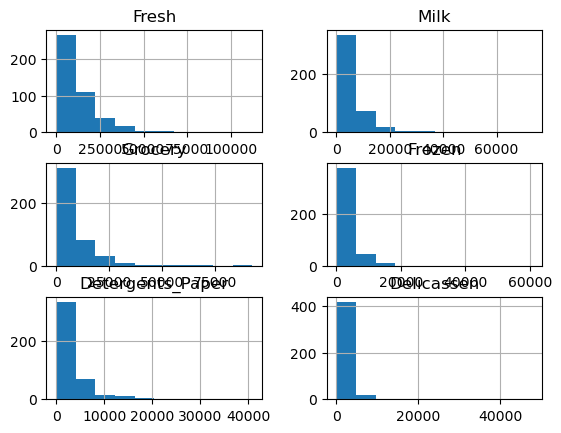

In [21]:
df.hist()

In [22]:
# Remove outliers
outlier_vars = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df = remove_outliers_iqr(df, outlier_vars)

(420, 6)
(396, 6)
(377, 6)
(340, 6)
(331, 6)
(318, 6)


array([[<Axes: title={'center': 'Fresh'}>,
        <Axes: title={'center': 'Milk'}>],
       [<Axes: title={'center': 'Grocery'}>,
        <Axes: title={'center': 'Frozen'}>],
       [<Axes: title={'center': 'Detergents_Paper'}>,
        <Axes: title={'center': 'Delicassen'}>]], dtype=object)

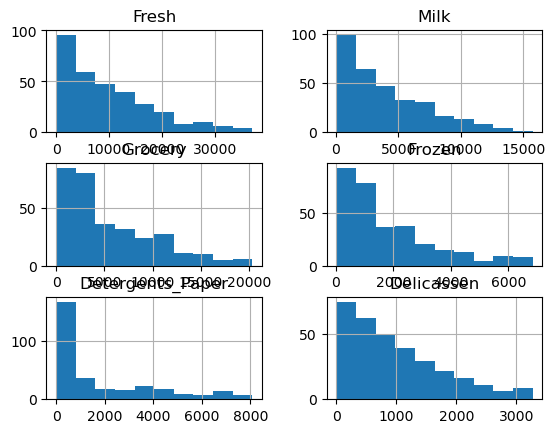

In [23]:
df.hist()

In [24]:
# Correlation-based filtering
df, dropped_vars = remove_highly_correlated(df)
print(dropped_vars)
df.shape

[]


(318, 6)

In [25]:
# Low-variance filtering
df, kept_vars = remove_low_variance(df)
print(kept_vars)
df.shape

['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


(318, 6)

In [26]:
# Scaling
X = df.copy()
X_scaled = scale_standard(X)
X_scaled

array([[ 0.36041979,  1.74071034,  0.43271395, -0.98480101,  0.37827742,
         0.45117793],
       [-0.32503941,  1.78801539,  0.86752557, -0.0233858 ,  0.65924069,
         1.00971769],
       [ 0.43321624, -0.8579957 , -0.29088884,  2.85961769, -0.60532095,
         1.02502015],
       ...,
       [ 0.85655936, -0.02063486,  0.52652234, -0.69041418,  0.24074613,
        -0.18642453],
       [ 0.06984469, -0.61686281, -0.7218008 , -0.47303994, -0.75919259,
         1.45476421],
       [-0.84658446, -0.70379352, -0.66157279, -1.07734033, -0.61893791,
        -1.18873561]], shape=(318, 6))

#### Clustering Modeling and Performance Evaluation

In [27]:
#######################################################
# Construct a model
from sklearn.cluster import KMeans
selected_k = 5  # number of resulting clusters
selected_n_init = 10    # number of times the k-means algorithm is run with different centroid seeds
model = KMeans(n_clusters=selected_k, n_init=selected_n_init, random_state=23)   

X_clusters = model.fit_predict(X_scaled)
#######################################################

# Performance Evaluation
silhouette, db, dunn, ch = evaluate_clustering(X_scaled, X_clusters)
print('Silhouette Index: ', silhouette)
print('Davies-Bouldin Index: ', db)
print('Dunn Index: ', dunn)
print('CH Index: ', ch)

Silhouette Index:  0.2702271378178718
Davies-Bouldin Index:  1.2693835691548778
Dunn Index:  0.3715477972279064
CH Index:  110.39129527976499


In [28]:
X_clusters

array([2, 1, 4, 2, 0, 2, 0, 1, 1, 0, 2, 1, 2, 0, 1, 2, 0, 2, 4, 0, 4, 0,
       2, 0, 3, 3, 0, 1, 1, 1, 2, 1, 1, 1, 4, 0, 1, 3, 0, 1, 0, 2, 0, 4,
       1, 4, 0, 1, 4, 0, 2, 3, 0, 0, 0, 1, 2, 3, 0, 2, 4, 1, 0, 0, 0, 0,
       4, 1, 1, 1, 0, 3, 1, 1, 3, 1, 3, 3, 0, 0, 0, 4, 4, 3, 0, 0, 1, 3,
       2, 0, 4, 0, 0, 0, 0, 0, 4, 0, 2, 0, 2, 2, 3, 0, 0, 0, 4, 3, 3, 0,
       3, 0, 0, 1, 3, 1, 1, 1, 3, 3, 1, 1, 0, 0, 0, 1, 0, 0, 1, 2, 0, 4,
       2, 1, 0, 0, 4, 4, 1, 1, 0, 0, 1, 0, 1, 4, 0, 0, 0, 0, 1, 0, 3, 0,
       1, 1, 1, 3, 0, 3, 1, 4, 0, 0, 2, 0, 0, 4, 0, 3, 0, 4, 0, 0, 4, 0,
       3, 3, 2, 2, 0, 3, 0, 4, 0, 2, 3, 0, 4, 0, 4, 3, 4, 1, 1, 3, 4, 0,
       0, 3, 0, 0, 3, 4, 2, 0, 2, 0, 0, 0, 0, 4, 1, 3, 0, 3, 0, 1, 0, 2,
       1, 1, 3, 0, 3, 4, 0, 0, 0, 0, 0, 0, 4, 0, 3, 4, 0, 4, 4, 3, 2, 0,
       1, 1, 1, 0, 0, 1, 2, 0, 0, 0, 4, 0, 3, 0, 3, 0, 0, 0, 0, 2, 0, 0,
       3, 0, 2, 0, 0, 1, 0, 0, 3, 2, 4, 3, 0, 3, 0, 4, 4, 0, 0, 0, 0, 1,
       4, 4, 0, 4, 3, 3, 4, 0, 1, 0, 0, 1, 4, 2, 1,

#### Cluster Interpretation

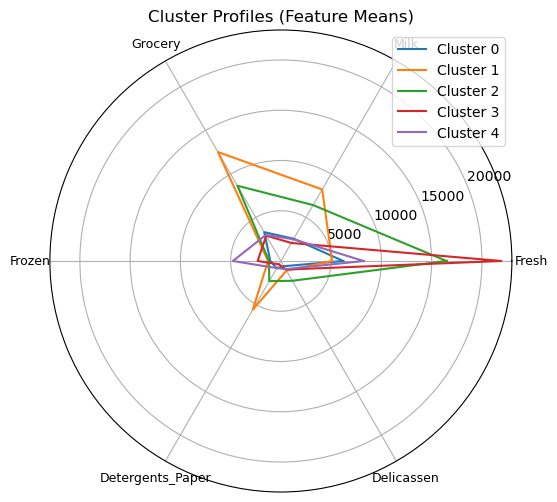

In [29]:
# Plot radar graph for feature means
# To visualize major feature representations of each cluster
create_radar_graph(X, X_clusters)

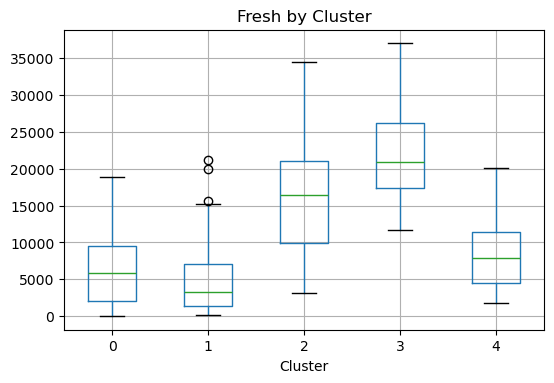

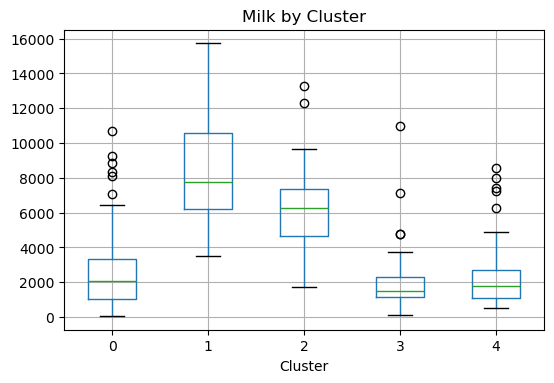

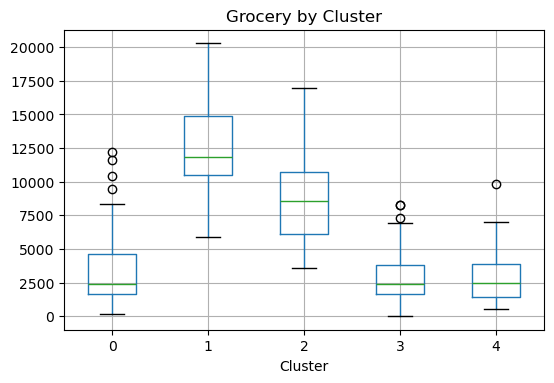

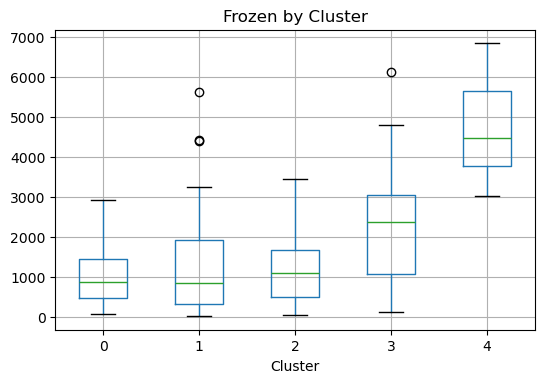

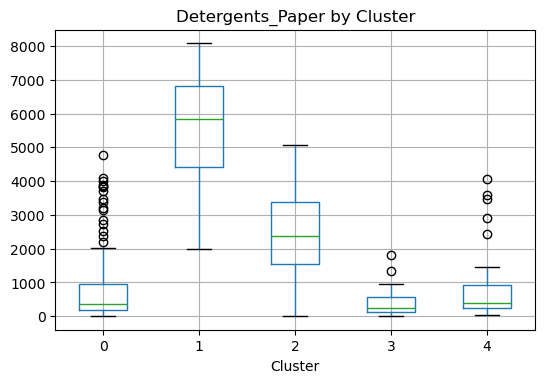

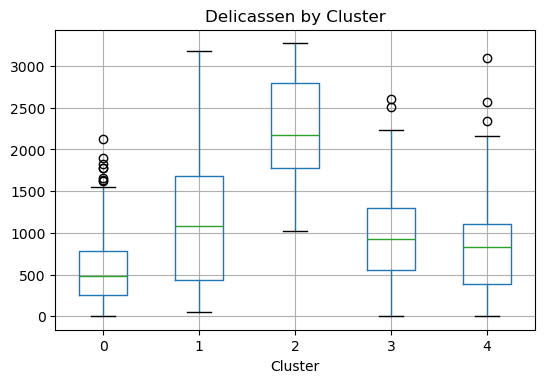

In [30]:
# Plot boxplot of feature values for all clusters
# To visualize variability within cluster
create_feature_boxplots(X, X_clusters)

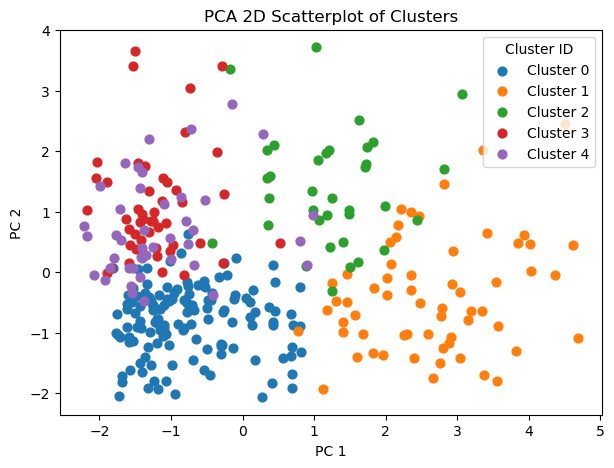

In [31]:
# Plot pca scatterplot, using the first two PC1 and PC2.
# To inspect cluster separation and overlap
create_pca_scatterplot(X_scaled, X_clusters)

In [32]:
# Compute permutation imporatance
# To find out which features determine cluster membership most
importance_df = get_permutation_importance(X_scaled, X_clusters)
print(importance_df)

            Feature  Importance
0             Fresh    0.247799
3            Frozen    0.217296
4  Detergents_Paper    0.146226
5        Delicassen    0.086478
2           Grocery    0.050629
1              Milk    0.042453


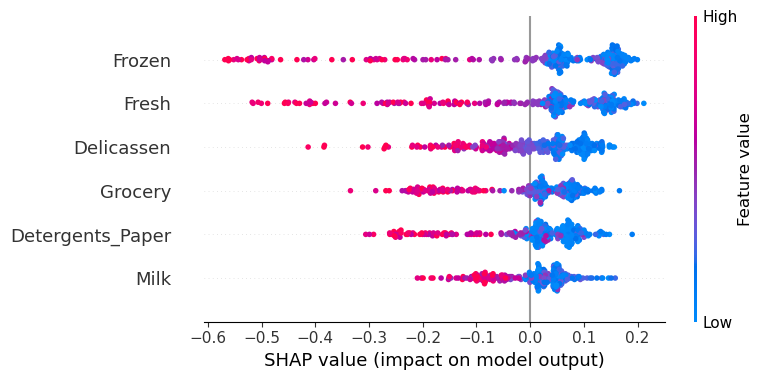

In [33]:
# Plot shap values
# To show feature contribution to that cluster
create_shap_values_plot(X_scaled, X_clusters, 0)  # 0 = cluster ID

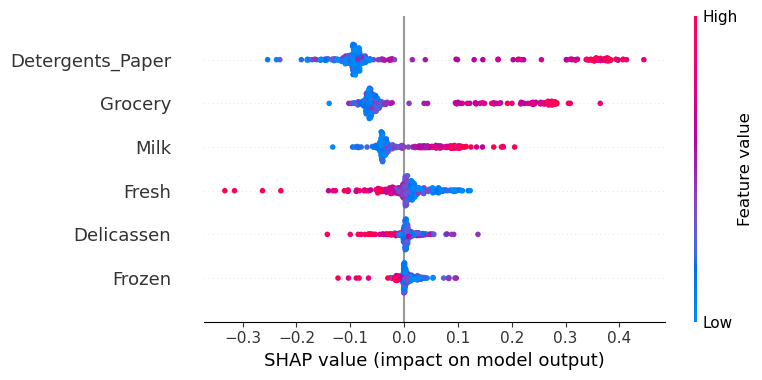

In [34]:
# Plot shap values
# To show feature contribution to that cluster
create_shap_values_plot(X_scaled, X_clusters, 1)  # 1 = cluster ID